# Domain Adversarial Training: ADReSS → Lu (XLSR)

**目标**: 使用域对抗训练，让模型学习跨数据集的通用AD检测特征

**训练策略**:
- **源域**: ADReSS（有标签，用于AD分类训练）
- **目标域**: Lu（训练时不使用标签，只用于域对抗）
- **验证**: 在Lu验证集上评估泛化性能

**核心思想**: 通过梯度反转层，让特征提取器学到"既能分类AD，又无法区分数据集"的特征


## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Add parent directory to path
script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, RANDOM_SEEDS, LEARNING_RATE, MAX_EPOCHS, WEIGHT_DECAY, XLSR_DROPOUT
from config import DANN_LAMBDA_CLASS, DANN_LAMBDA_DOMAIN  # 新增：导入损失权重
from model_DANN import AD_XLSR_Model_DANN, compute_alpha, print_dann_model_info
from dataset import create_dataloaders
from visualization import plot_training_curves

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [2]:
SOURCE_DATASET = "ADReSS"
TARGET_DATASET = "Lu"

# 域对抗阶段控制
DOMAIN_WARMUP_EPOCHS = 20    # 前20个epoch仅训练源域分类器
DOMAIN_ANNEAL_RATIO = 0.25   # 之后25% epoch线性上升到最大lambda

# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Source Domain: {SOURCE_DATASET}")
print(f"Target Domain: {TARGET_DATASET}")
print(f"Device: {device}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Max Epochs: {MAX_EPOCHS}")
print(f"Lambda Class: {DANN_LAMBDA_CLASS}")
print(f"Lambda Domain: {DANN_LAMBDA_DOMAIN}")
print(f"Domain Warmup Epochs: {DOMAIN_WARMUP_EPOCHS}")
print(f"Domain Anneal Ratio: {DOMAIN_ANNEAL_RATIO}")


Source Domain: ADReSS
Target Domain: Lu
Device: mps
Learning Rate: 0.003
Max Epochs: 100
Lambda Class: 1.0
Lambda Domain: 0.1
Domain Warmup Ratio: 0.5
Domain Anneal Ratio: 0.25


In [3]:
# File paths
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-xlsr-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-xlsr-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"DANN_{SOURCE_DATASET}_to_{TARGET_DATASET}_xlsr"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load Data

In [4]:
source_train_loader = create_dataloaders(data_csv=SOURCE_TRAIN_CSV, xlsr=True)

# 加载ADReSS验证集（用于评估源域性能）
SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"
source_val_loader = create_dataloaders(data_csv=SOURCE_VAL_CSV, xlsr=True)

target_train_loader = create_dataloaders(data_csv=TARGET_TRAIN_CSV, xlsr=True)
target_val_loader = create_dataloaders(data_csv=TARGET_VAL_CSV, xlsr=True)

source_val_size = len(source_val_loader.dataset)
target_val_size = len(target_val_loader.dataset)
val_total = source_val_size + target_val_size
SOURCE_WEIGHT = source_val_size / val_total
TARGET_WEIGHT = target_val_size / val_total

print(f"Source validation samples: {source_val_size}")
print(f"Target validation samples: {target_val_size}")
print(f"Model selection weights -> Source: {SOURCE_WEIGHT:.3f}, Target: {TARGET_WEIGHT:.3f}")


Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 32 samples
Control: 16, Dementia: 16


Loading completed: 42 samples
Control: 20, Dementia: 22


Loading completed: 11 samples
Control: 5, Dementia: 6


Source validation samples: 32
Target validation samples: 11
Model selection weights -> Source: 0.744, Target: 0.256


## 4. Model Architecture

In [5]:
# Show model architecture
test_model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT)
print_dann_model_info(test_model, "XLSR")


DANN Model Architecture (XLSR)
Total Parameters: 710,085
Trainable Parameters: 710,085

Parameter Distribution:
  - Feature Extractor: 705,569 (99.4%)
  - Class Classifier: 66 (0.0%)
  - Domain Classifier: 4,450 (0.6%)



## 5. Define Training Functions


In [6]:
def compute_domain_lambda(epoch, total_epochs, base_lambda=DANN_LAMBDA_DOMAIN,
                         warmup_epochs=DOMAIN_WARMUP_EPOCHS, anneal_ratio=DOMAIN_ANNEAL_RATIO):
    """根据epoch调度域损失权重。
    - warmup阶段: 前warmup_epochs个epoch，lambda=0，仅训练源域分类器
    - 之后按照anneal_ratio比例线性上升到base_lambda
    - 剩余阶段: 维持base_lambda
    """
    warmup_epochs = min(warmup_epochs, total_epochs)
    anneal_epochs = int(total_epochs * anneal_ratio)
    if epoch <= warmup_epochs:
        return 0.0
    if anneal_epochs <= 0:
        return base_lambda
    progress = min(1.0, max(0, epoch - warmup_epochs) / max(1, anneal_epochs))
    return base_lambda * progress


In [7]:
def train_one_epoch_dann(model, source_loader, target_loader, optimizer, device, epoch, total_epochs, 
                         lambda_class=DANN_LAMBDA_CLASS, lambda_domain=DANN_LAMBDA_DOMAIN):
    """训练一个epoch with DANN
    
    Args:
        lambda_class: 分类损失权重 (默认: 1.0)
        lambda_domain: 当前epoch的域对抗损失权重
    """
    model.train()
    
    total_class_loss = 0
    total_domain_loss = 0
    correct = 0
    total = 0
    domain_correct = 0
    domain_total = 0
    
    target_iter = iter(target_loader)
    len_source = len(source_loader)
    total_steps = total_epochs * len_source
    lambda_active = lambda_domain > 0
    
    pbar = tqdm(enumerate(source_loader), total=len_source, desc=f"Epoch {epoch}", leave=False)
    
    for i, source_batch in pbar:
        # 计算alpha (梯度反转强度)
        current_step = (epoch - 1) * len_source + i
        alpha = compute_alpha(current_step, total_steps)
        
        # ===== 处理源域数据 =====
        source_features, source_labels, source_masks = source_batch
        source_features = source_features.to(device)
        source_labels = source_labels.to(device)
        source_masks = source_masks.to(device)
        
        if lambda_active:
            class_output, domain_output = model(
                source_features,
                mask=source_masks,
                alpha=alpha,
                return_features=True
            )
        else:
            class_output = model(
                source_features,
                mask=source_masks,
                alpha=alpha,
                return_features=False
            )
            domain_output = None
        
        # 源域的域标签 = 0
        source_domain_labels = torch.zeros(source_labels.size(0), dtype=torch.long).to(device)
        
        # 计算分类损失
        loss_class = F.cross_entropy(class_output, source_labels)
        
        if lambda_active:
            loss_domain_source = F.cross_entropy(domain_output, source_domain_labels)
            try:
                target_batch = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                target_batch = next(target_iter)
            target_features, _, target_masks = target_batch  # 不使用目标域标签!
            target_features = target_features.to(device)
            target_masks = target_masks.to(device)
            _, domain_output_target = model(
                target_features,
                mask=target_masks,
                alpha=alpha,
                return_features=True
            )
            target_domain_labels = torch.ones(target_features.size(0), dtype=torch.long).to(device)
            loss_domain_target = F.cross_entropy(domain_output_target, target_domain_labels)
        else:
            loss_domain_source = torch.zeros(1, device=device)
            loss_domain_target = torch.zeros(1, device=device)
            target_domain_labels = None
            domain_output_target = None
        
        total_batch_loss = (lambda_class * loss_class +
                           lambda_domain * (loss_domain_source + loss_domain_target))
        
        optimizer.zero_grad()
        total_batch_loss.backward()
        optimizer.step()
        
        total_class_loss += loss_class.item()
        total_domain_loss += (loss_domain_source.item() + loss_domain_target.item())
        
        predictions = torch.argmax(class_output, dim=1)
        correct += (predictions == source_labels).sum().item()
        total += source_labels.size(0)
        
        if lambda_active:
            domain_pred_source = torch.argmax(domain_output, dim=1)
            domain_pred_target = torch.argmax(domain_output_target, dim=1)
            domain_correct += (domain_pred_source == source_domain_labels).sum().item()
            domain_correct += (domain_pred_target == target_domain_labels).sum().item()
            domain_total += source_domain_labels.size(0) + target_domain_labels.size(0)
        
        pbar.set_postfix({
            'α': f'{alpha:.2f}',
            'λ_dom': f'{lambda_domain:.3f}',
            'cls': f'{loss_class.item():.3f}',
            'dom': f'{(loss_domain_source.item() + loss_domain_target.item()):.3f}',
            'acc': f'{correct/total:.3f}'
        })
    
    avg_class_loss = total_class_loss / len_source
    avg_domain_loss = total_domain_loss / len_source
    train_acc = correct / total
    domain_acc = (domain_correct / domain_total) if domain_total > 0 else 0.0
    
    return avg_class_loss, avg_domain_loss, train_acc, domain_acc


In [8]:
def validate_dann(model, val_loader, device):
    """验证DANN模型"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    control_correct, control_total = 0, 0
    dementia_correct, dementia_total = 0, 0
    tp, fp, fn = 0, 0, 0
    
    with torch.no_grad():
        for features, labels, masks in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            masks = masks.to(device)
            
            logits = model(features, mask=masks, return_features=False)
            
            loss = F.cross_entropy(logits, labels)
            predictions = torch.argmax(logits, dim=1)
            
            total_loss += loss.item()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            for pred, label in zip(predictions, labels):
                if label == 0:
                    control_total += 1
                    if pred == label:
                        control_correct += 1
                else:
                    dementia_total += 1
                    if pred == label:
                        dementia_correct += 1
                
                if pred == 1 and label == 1:
                    tp += 1
                elif pred == 1 and label == 0:
                    fp += 1
                elif pred == 0 and label == 1:
                    fn += 1
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    control_acc = control_correct / control_total if control_total > 0 else 0
    dementia_acc = dementia_correct / dementia_total if dementia_total > 0 else 0
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return avg_loss, accuracy, control_acc, dementia_acc, f1_score

In [9]:
def train_dann(seed, source_train_loader, target_train_loader, source_val_loader, target_val_loader, 
               output_dir, device, source_weight=0.5, target_weight=0.5):
    """完整的DANN训练流程"""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    
    seed_dir = Path(output_dir) / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    
    model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    history = {
        'epochs': [],
        'train_class_losses': [],
        'train_domain_losses': [],
        'train_accs': [],
        'source_val_accs': [],
        'target_val_accs': [],
        'avg_val_accs': [],
        'val_losses': [],
        'val_accs': [],
        'domain_accs': [],
        'lambda_domains': []
    }
    
    best_avg_acc = 0
    best_metrics = {}
    patience = 15
    patience_counter = 0
    
    print(f"\n{'='*60}")
    print(f"Training Seed {seed}")
    print(f"Model Selection: Average Accuracy (Source {source_weight:.3f}, Target {target_weight:.3f})")
    print(f"{'='*60}")
    
    for epoch in range(1, MAX_EPOCHS + 1):
        current_lambda_domain = compute_domain_lambda(epoch, MAX_EPOCHS)
        class_loss, domain_loss, train_acc, domain_acc = train_one_epoch_dann(
            model, source_train_loader, target_train_loader, optimizer, device, epoch, MAX_EPOCHS,
            lambda_class=DANN_LAMBDA_CLASS,
            lambda_domain=current_lambda_domain
        )
        
        source_val_loss, source_val_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
            model, source_val_loader, device
        )
        
        target_val_loss, target_val_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
            model, target_val_loader, device
        )
        
        avg_val_acc = source_weight * source_val_acc + target_weight * target_val_acc
        
        history['epochs'].append(epoch)
        history['train_class_losses'].append(class_loss)
        history['train_domain_losses'].append(domain_loss)
        history['train_accs'].append(train_acc)
        history['source_val_accs'].append(source_val_acc)
        history['target_val_accs'].append(target_val_acc)
        history['avg_val_accs'].append(avg_val_acc)
        history['val_losses'].append(target_val_loss)
        history['val_accs'].append(target_val_acc)
        history['domain_accs'].append(domain_acc)
        history['lambda_domains'].append(current_lambda_domain)
        
        print(f"Epoch {epoch:3d} | Train: {train_acc:.3f} | Source Val: {source_val_acc:.3f} | "
              f"Target Val: {target_val_acc:.3f} | Avg: {avg_val_acc:.3f} | Domain: {domain_acc:.3f} | "
              f"λ_dom: {current_lambda_domain:.3f}")
        
        if avg_val_acc > best_avg_acc:
            best_avg_acc = avg_val_acc
            best_metrics = {
                'avg_val_acc': avg_val_acc,
                'source_val_acc': source_val_acc,
                'target_val_acc': target_val_acc,
                'source_val_loss': source_val_loss,
                'target_val_loss': target_val_loss,
                'source_control_acc': source_control_acc,
                'source_dementia_acc': source_dementia_acc,
                'target_control_acc': target_control_acc,
                'target_dementia_acc': target_dementia_acc,
                'source_f1': source_f1,
                'target_f1': target_f1,
                'epoch': epoch
            }
            patience_counter = 0
            torch.save(model.state_dict(), seed_dir / 'best_dann.pth')
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    print(f"\nBest Results (Epoch {best_metrics['epoch']}):")
    print(f"  Avg Acc: {best_metrics['avg_val_acc']*100:.2f}%")
    print(f"  Source (ADReSS): {best_metrics['source_val_acc']*100:.2f}% | F1: {best_metrics['source_f1']:.4f}")
    print(f"  Target (Lu): {best_metrics['target_val_acc']*100:.2f}% | F1: {best_metrics['target_f1']:.4f}")
    
    return seed, best_metrics, history


In [10]:
def evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device):
    """评估模型在两个数据集上的性能并可视化"""
    print(f"{'='*60}")
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"{'='*60}")
 
    best_model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))
    
    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
        best_model, target_val_loader, device
    )
    
    print(f"{'Dataset':<15} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print(f"{'-'*75}")
    print(f"{'ADReSS (源域)':<15} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{'Lu (目标域)':<15} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print(f"{'-'*75}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    datasets = ['ADReSS (源域)', 'Lu(目标域)']
    accuracies = [source_acc * 100, target_acc * 100]
    colors = ['#3498db', '#e74c3c']
    bars = axes[0].bar(datasets, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'Performance Comparison (Seed {seed})', fontsize=13, fontweight='bold')
    axes[0].set_ylim(0, 100)
    axes[0].grid(True, alpha=0.3, axis='y')
    for bar, acc in zip(bars, accuracies):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2, f'{acc:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    metrics_names = ['Accuracy', 'F1 Score', 'Dementia Acc', 'Control Acc']
    source_vals = [source_acc*100, source_f1*100, source_dementia_acc*100, source_control_acc*100]
    target_vals = [target_acc*100, target_f1*100, target_dementia_acc*100, target_control_acc*100]
    x = np.arange(len(metrics_names))
    width = 0.35
    bars1 = axes[1].bar(x - width/2, source_vals, width, label='ADReSS (源域)', 
                        color='#3498db', alpha=0.7, edgecolor='black')
    bars2 = axes[1].bar(x + width/2, target_vals, width, label='Lu (目标域)', 
                        color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[1].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
    axes[1].set_title(f'Detailed Metrics Comparison (Seed {seed})', fontsize=13, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics_names, fontsize=10)
    axes[1].legend(fontsize=10)
    axes[1].set_ylim(0, 110)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Seed {seed} 评估完成")
    
    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics


## 6. Training with Multiple Seeds


In [11]:
# 存储所有种子的结果
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'source_metrics': [],  # ADReSS验证集结果
    'target_metrics': []   # Lu验证集结果
}

print(f"将训练 {len(RANDOM_SEEDS)} 个不同的随机种子: {RANDOM_SEEDS}")


将训练 5 个不同的随机种子: [21, 42, 84, 168, 336]


### Seed 1: 21



Training Seed 21
Model Selection: Average Accuracy (Source 0.744, Target 0.256)


Epoch   1 | Train: 0.565 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.573 | Source Val: 0.562 | Target Val: 0.455 | Avg: 0.535 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.613 | Source Val: 0.594 | Target Val: 0.455 | Avg: 0.558 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.653 | Source Val: 0.562 | Target Val: 0.455 | Avg: 0.535 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  34 | Train: 0.952 | Source Val: 0.594 | Target Val: 0.727 | Avg: 0.628 | Domain: 0.000 | λ_dom: 0.000


Epoch  35 | Train: 0.952 | Source Val: 0.594 | Target Val: 0.818 | Avg: 0.651 | Domain: 0.000 | λ_dom: 0.000


Epoch  36 | Train: 0.976 | Source Val: 0.594 | Target Val: 0.818 | Avg: 0.651 | Domain: 0.000 | λ_dom: 0.000


Epoch  37 | Train: 0.976 | Source Val: 0.594 | Target Val: 0.727 | Avg: 0.628 | Domain: 0.000 | λ_dom: 0.000


Epoch  38 | Train: 0.976 | Source Val: 0.719 | Target Val: 0.727 | Avg: 0.721 | Domain: 0.000 | λ_dom: 0.000
Early stopping at epoch 38

Best Results (Epoch 23):
  Avg Acc: 76.74%
  Source (ADReSS): 87.50% | F1: 0.8667
  Target (Lu): 45.45% | F1: 0.0000


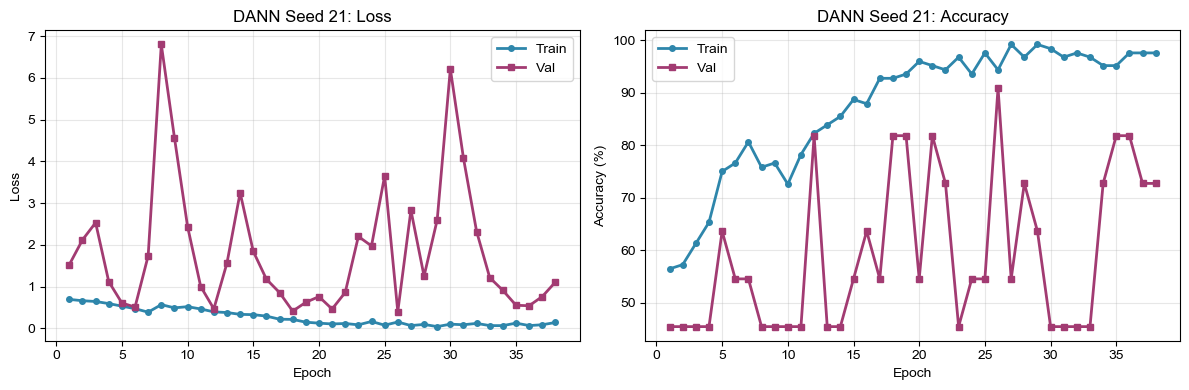

In [12]:
seed, metrics, history = train_dann(
    seed=21,
    source_train_loader=source_train_loader,
    target_train_loader=target_train_loader,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT
)

all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)

# 可视化训练曲线
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_class_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'DANN Seed {seed}'
)


Evaluating Best Model (Seed 21)
Dataset         Accuracy     F1 Score     Dementia     Control      Loss      
---------------------------------------------------------------------------
ADReSS (源域)          87.50%      0.8667       81.25%       93.75%    0.5608
Lu (目标域)             45.45%      0.0000        0.00%      100.00%    2.2032
---------------------------------------------------------------------------


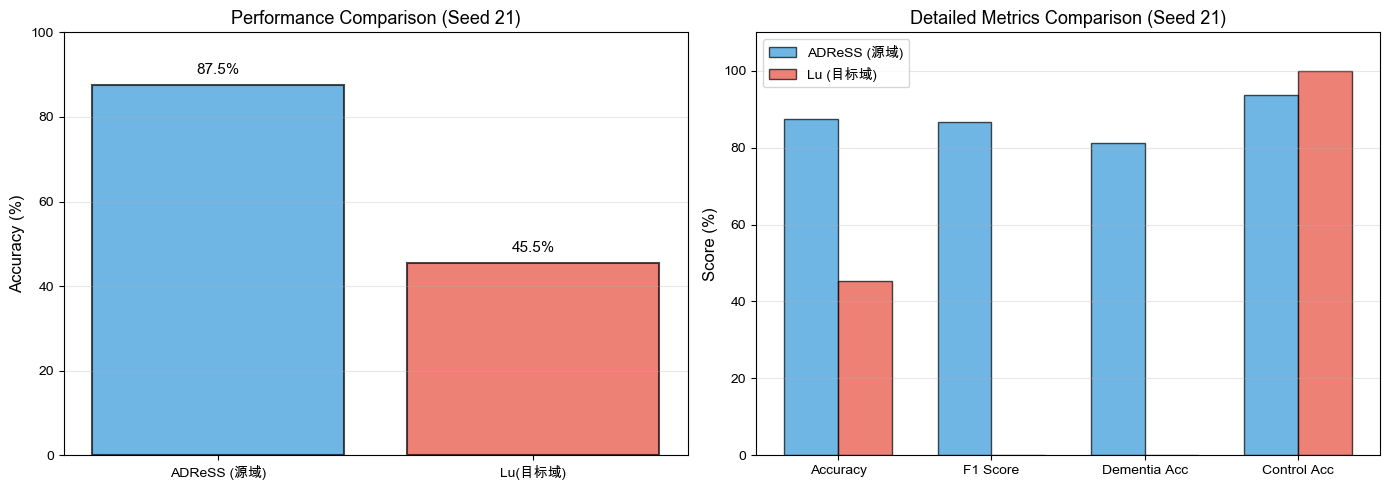

✓ Seed 21 评估完成


In [13]:
# 评估并可视化
model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(
    seed, source_val_loader, target_val_loader, model_path, device
)

# 保存结果
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


Seed 42


Training Seed 42
Model Selection: Average Accuracy (Source 0.744, Target 0.256)


Epoch   1 | Train: 0.524 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.556 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.597 | Source Val: 0.562 | Target Val: 0.455 | Avg: 0.535 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.605 | Source Val: 0.562 | Target Val: 0.455 | Avg: 0.535 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  45 | Train: 1.000 | Source Val: 0.594 | Target Val: 0.818 | Avg: 0.651 | Domain: 0.000 | λ_dom: 0.000


Epoch  46 | Train: 0.976 | Source Val: 0.594 | Target Val: 0.636 | Avg: 0.605 | Domain: 0.000 | λ_dom: 0.000


Epoch  47 | Train: 0.927 | Source Val: 0.594 | Target Val: 0.727 | Avg: 0.628 | Domain: 0.000 | λ_dom: 0.000


Epoch  48 | Train: 0.927 | Source Val: 0.719 | Target Val: 0.455 | Avg: 0.651 | Domain: 0.000 | λ_dom: 0.000


Epoch  49 | Train: 0.927 | Source Val: 0.625 | Target Val: 0.455 | Avg: 0.581 | Domain: 0.000 | λ_dom: 0.000
Early stopping at epoch 49

Best Results (Epoch 34):
  Avg Acc: 79.07%
  Source (ADReSS): 75.00% | F1: 0.7895
  Target (Lu): 90.91% | F1: 0.9231


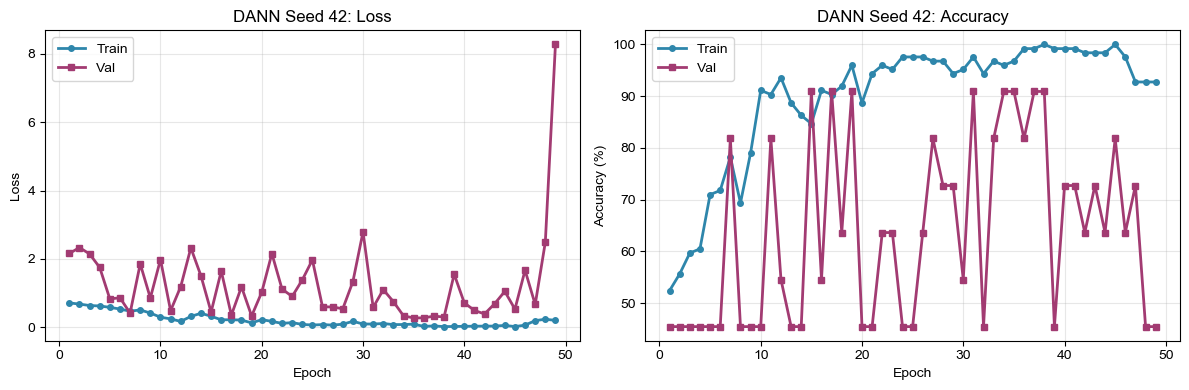

Evaluating Best Model (Seed 42)
Dataset         Accuracy     F1 Score     Dementia     Control      Loss      
---------------------------------------------------------------------------
ADReSS (源域)          75.00%      0.7895       93.75%       56.25%    0.9712
Lu (目标域)             90.91%      0.9231      100.00%       80.00%    0.3386
---------------------------------------------------------------------------


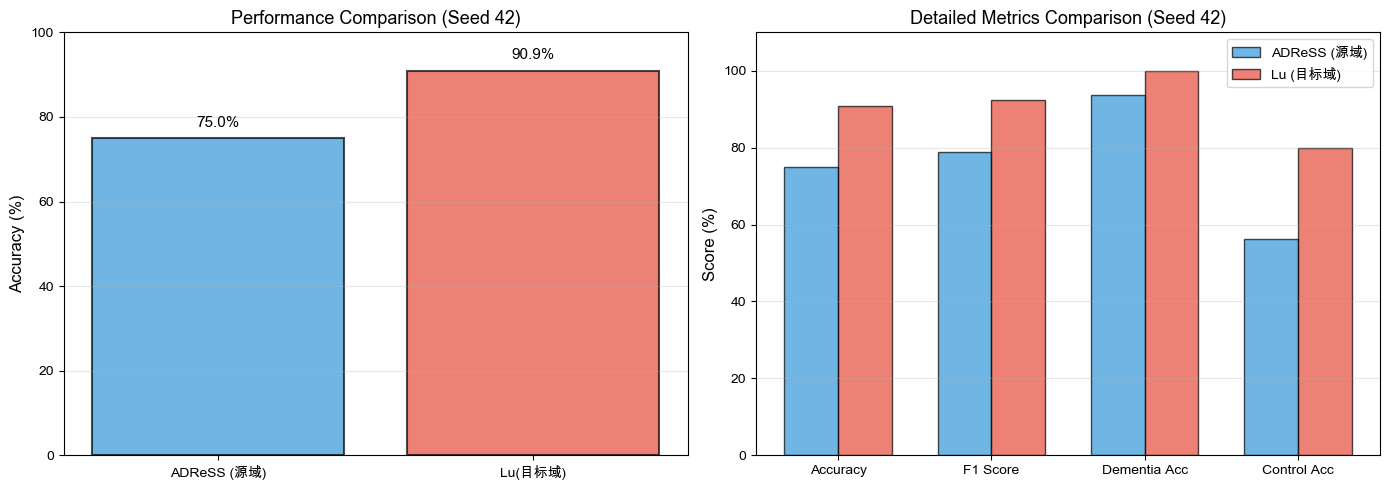

✓ Seed 42 评估完成


In [14]:
seed, metrics, history = train_dann(42, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

# 评估并可视化
model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 3: 84


Training Seed 84
Model Selection: Average Accuracy (Source 0.744, Target 0.256)


Epoch   1 | Train: 0.484 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.573 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.597 | Source Val: 0.562 | Target Val: 0.455 | Avg: 0.535 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.661 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  45 | Train: 1.000 | Source Val: 0.625 | Target Val: 0.455 | Avg: 0.581 | Domain: 0.000 | λ_dom: 0.000


Epoch  46 | Train: 0.976 | Source Val: 0.594 | Target Val: 0.909 | Avg: 0.674 | Domain: 0.000 | λ_dom: 0.000


Epoch  47 | Train: 0.952 | Source Val: 0.562 | Target Val: 0.455 | Avg: 0.535 | Domain: 0.000 | λ_dom: 0.000


Epoch  48 | Train: 0.919 | Source Val: 0.562 | Target Val: 0.818 | Avg: 0.628 | Domain: 0.000 | λ_dom: 0.000


Epoch  49 | Train: 0.927 | Source Val: 0.594 | Target Val: 0.727 | Avg: 0.628 | Domain: 0.000 | λ_dom: 0.000
Early stopping at epoch 49

Best Results (Epoch 34):
  Avg Acc: 79.07%
  Source (ADReSS): 75.00% | F1: 0.7895
  Target (Lu): 90.91% | F1: 0.9231


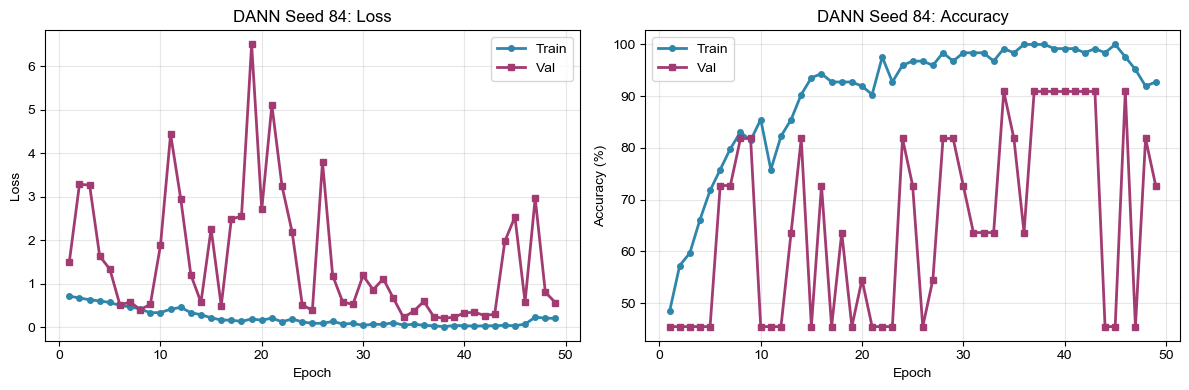

Evaluating Best Model (Seed 84)
Dataset         Accuracy     F1 Score     Dementia     Control      Loss      
---------------------------------------------------------------------------
ADReSS (源域)          75.00%      0.7895       93.75%       56.25%    0.5296
Lu (目标域)             90.91%      0.9231      100.00%       80.00%    0.2223
---------------------------------------------------------------------------


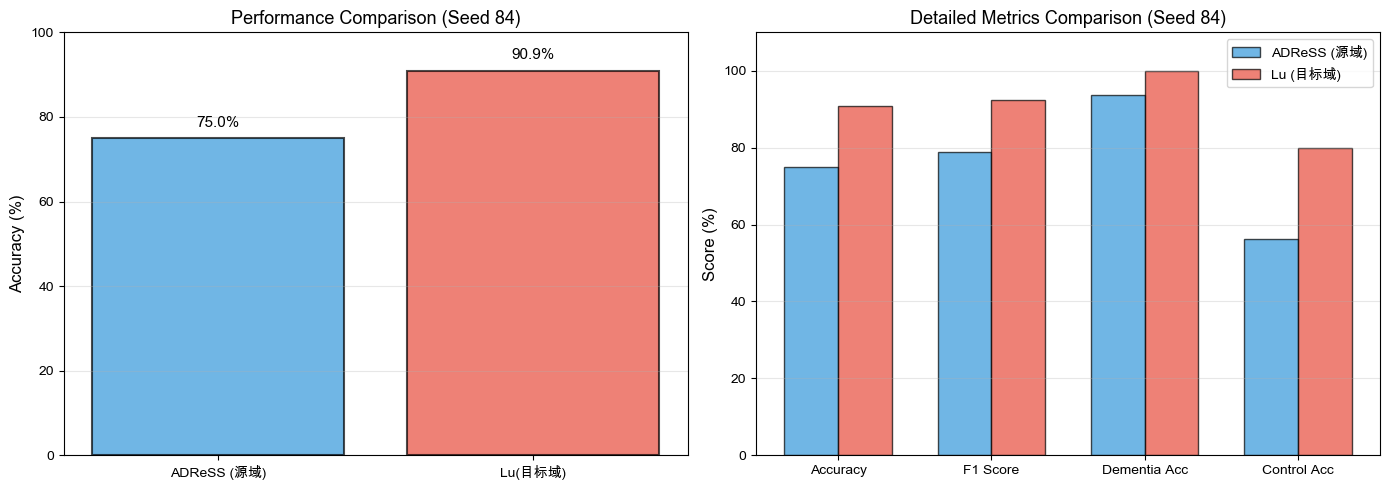

✓ Seed 84 评估完成


In [15]:
seed, metrics, history = train_dann(84, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

# 评估并可视化
model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 4: 168



Training Seed 168
Model Selection: Average Accuracy (Source 0.744, Target 0.256)


Epoch   1 | Train: 0.565 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.629 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.629 | Source Val: 0.531 | Target Val: 0.455 | Avg: 0.512 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.653 | Source Val: 0.594 | Target Val: 0.455 | Avg: 0.558 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  29 | Train: 0.960 | Source Val: 0.719 | Target Val: 0.636 | Avg: 0.698 | Domain: 0.000 | λ_dom: 0.000


Epoch  30 | Train: 0.968 | Source Val: 0.812 | Target Val: 0.545 | Avg: 0.744 | Domain: 0.000 | λ_dom: 0.000


Epoch  31 | Train: 0.976 | Source Val: 0.750 | Target Val: 0.545 | Avg: 0.698 | Domain: 0.000 | λ_dom: 0.000


Epoch  32 | Train: 0.976 | Source Val: 0.781 | Target Val: 0.545 | Avg: 0.721 | Domain: 0.000 | λ_dom: 0.000


Epoch  33 | Train: 1.000 | Source Val: 0.688 | Target Val: 0.455 | Avg: 0.628 | Domain: 0.000 | λ_dom: 0.000
Early stopping at epoch 33

Best Results (Epoch 18):
  Avg Acc: 74.42%
  Source (ADReSS): 78.12% | F1: 0.8000
  Target (Lu): 63.64% | F1: 0.5000


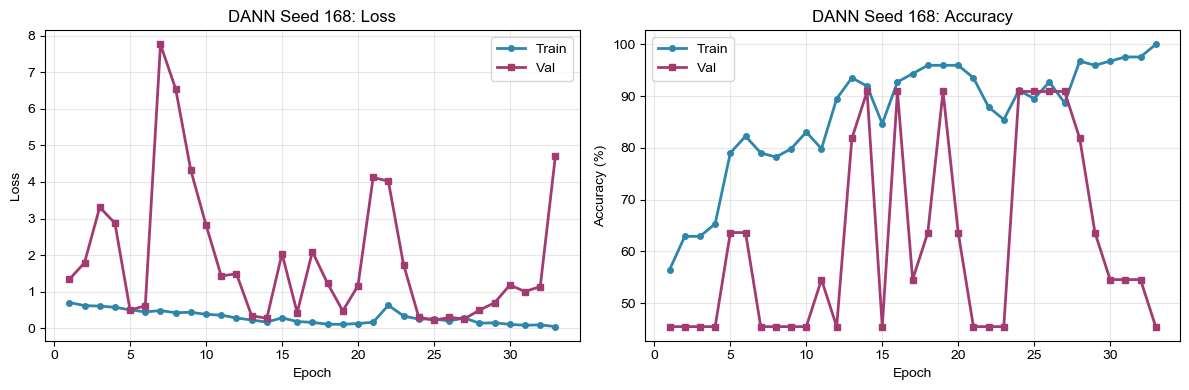

Evaluating Best Model (Seed 168)
Dataset         Accuracy     F1 Score     Dementia     Control      Loss      
---------------------------------------------------------------------------
ADReSS (源域)          78.12%      0.8000       87.50%       68.75%    0.4715
Lu (目标域)             63.64%      0.5000       33.33%      100.00%    1.2281
---------------------------------------------------------------------------


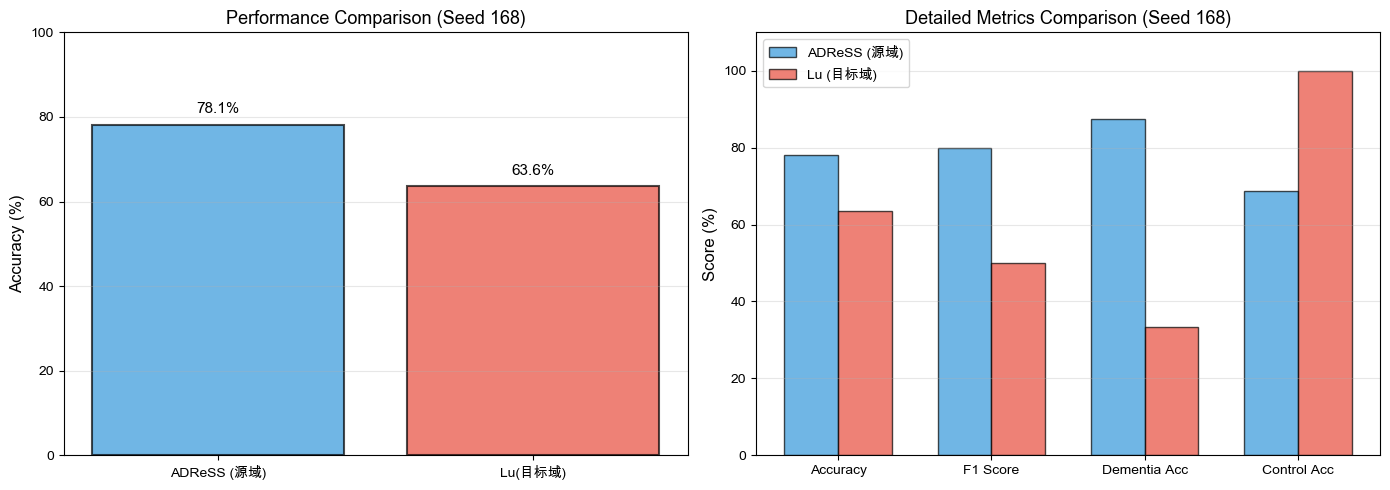

✓ Seed 168 评估完成


In [16]:
seed, metrics, history = train_dann(168, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

# 评估并可视化
model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 5: 336



Training Seed 336
Model Selection: Average Accuracy (Source 0.744, Target 0.256)


Epoch   1 | Train: 0.556 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.597 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.597 | Source Val: 0.594 | Target Val: 0.455 | Avg: 0.558 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.742 | Source Val: 0.500 | Target Val: 0.455 | Avg: 0.488 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  27 | Train: 0.903 | Source Val: 0.688 | Target Val: 0.545 | Avg: 0.651 | Domain: 0.000 | λ_dom: 0.000


Epoch  28 | Train: 0.879 | Source Val: 0.625 | Target Val: 0.636 | Avg: 0.628 | Domain: 0.000 | λ_dom: 0.000


Epoch  29 | Train: 0.790 | Source Val: 0.625 | Target Val: 0.545 | Avg: 0.605 | Domain: 0.000 | λ_dom: 0.000


Epoch  30 | Train: 0.871 | Source Val: 0.750 | Target Val: 0.455 | Avg: 0.674 | Domain: 0.000 | λ_dom: 0.000


Epoch  31 | Train: 0.911 | Source Val: 0.656 | Target Val: 0.636 | Avg: 0.651 | Domain: 0.000 | λ_dom: 0.000
Early stopping at epoch 31

Best Results (Epoch 16):
  Avg Acc: 76.74%
  Source (ADReSS): 75.00% | F1: 0.7895
  Target (Lu): 81.82% | F1: 0.8333


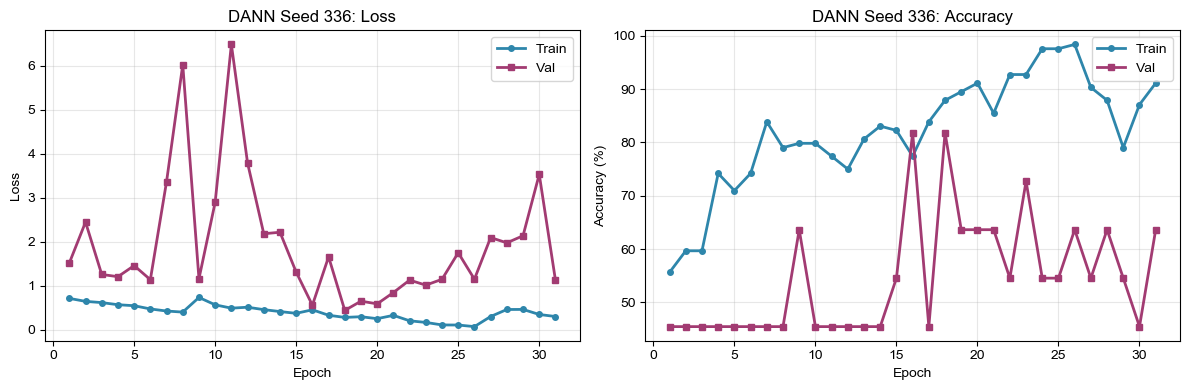

Evaluating Best Model (Seed 336)
Dataset         Accuracy     F1 Score     Dementia     Control      Loss      
---------------------------------------------------------------------------
ADReSS (源域)          75.00%      0.7895       93.75%       56.25%    0.4924
Lu (目标域)             81.82%      0.8333       83.33%       80.00%    0.5546
---------------------------------------------------------------------------


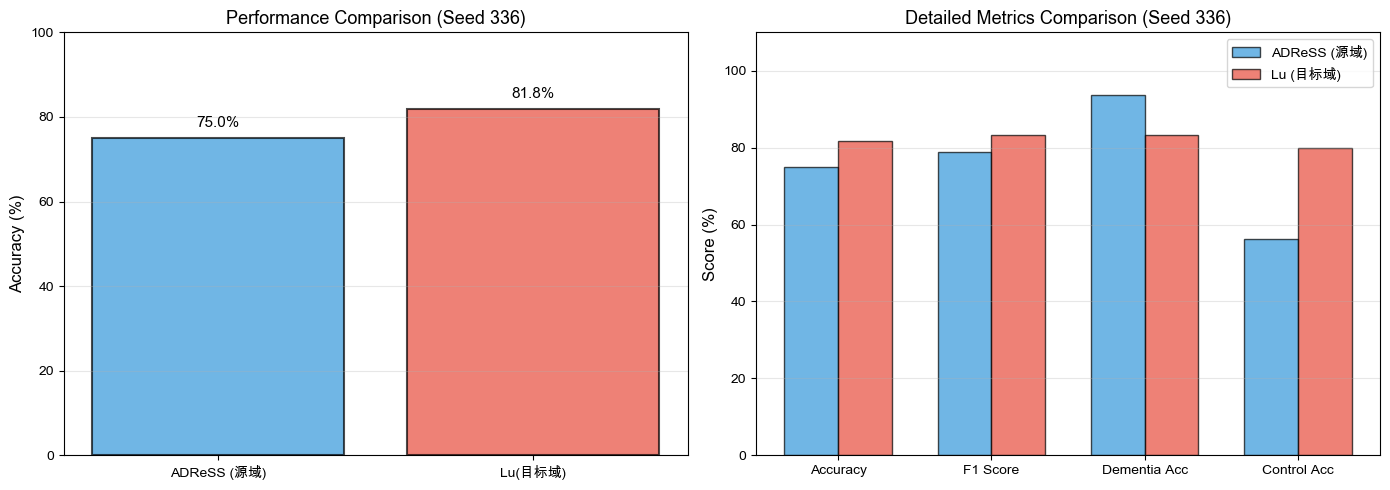

✓ Seed 336 评估完成


In [17]:
seed, metrics, history = train_dann(336, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

# 评估并可视化
model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


## 7. Summary and Visualization


In [18]:
# 汇总所有结果 - 两个数据集对比
seeds = all_results['seeds']

# ADReSS (源域) 结果
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Lu (目标域) 结果
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"\n{'='*90}")
print(f"DANN Training Results Summary: {SOURCE_DATASET} → {TARGET_DATASET} (XLSR)")
print(f"{'='*90}\n")

print(f"{'Dataset':<20} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{'ADReSS (源域)':<20} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>5.4f}  {np.mean(source_losses):>10.4f}")
print(f"{'Lu (目标域)':<20} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>5.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\n")

print(f"详细结果 (所有Seeds):")
print(f"\n{'Seed':<8} {'Dataset':<15} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {'ADReSS (源域)':<15} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':<8} {'Lu (目标域)':<15} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")


DANN Training Results Summary: ADReSS → Lu (XLSR)

Dataset              Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
ADReSS (源域)           78.12% ± 4.84%    0.8070 ± 0.0301      0.6051
Lu (目标域)              74.55% ± 17.63%    0.6359 ± 0.3541      0.9093
------------------------------------------------------------------------------------------

详细结果 (所有Seeds):

Seed     Dataset         Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       ADReSS (源域)          87.50%      0.8667       81.25%       93.75%    0.5608
         Lu (目标域)             45.45%      0.0000        0.00%      100.00%    2.2032
------------------------------------------------------------------------------------------
42       ADReSS (源域)          75.00%      0.7895       93.75%       56.25%    0.9712
       